<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/15_debt_sustainability_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Baseline Macroeconomic Calibration
INITIAL_DEBT_RATIO = 81.5  # Initial Debt-to-GDP (%)
YEARS = 7  # 7-Year Forward Projection Horizon
SIMULATIONS = 1000  # Number of Monte Carlo Stochastic Paths

# Projected Baseline Means
MEAN_NOMINAL_GROWTH = 0.105  # 10.5% Nominal GDP growth
MEAN_INTEREST_RATE = 0.072  # 7.2% Effective borrowing cost
MEAN_PRIMARY_BALANCE = -0.025  # Primary Deficit of 2.5% of GDP

# Macro Shocks Volatility (Standard Deviations)
STD_GROWTH = 0.018  # Volatility in GDP growth
STD_INTEREST = 0.008  # Volatility in borrowing costs
STD_PRIMARY_BALANCE = 0.009  # Fiscal slippage risk

# Projection timeline
years_range = [f"Y+{t}" for t in range(1, YEARS + 1)]

print(f"Baseline Debt: {INITIAL_DEBT_RATIO}% of GDP")
print(f"Simulation Setup: {SIMULATIONS:,} runs across {YEARS} projection years.")

Baseline Debt: 81.5% of GDP
Simulation Setup: 1,000 runs across 7 projection years.


In [2]:
# Set reproducible seed
np.random.seed(42)

# Array to store simulated debt trajectories: Shape (SIMULATIONS, YEARS + 1)
debt_trajectories = np.zeros((SIMULATIONS, YEARS + 1))
debt_trajectories[:, 0] = INITIAL_DEBT_RATIO

# Run simulation steps year-over-year
for t in range(1, YEARS + 1):
    # Draw stochastic shocks from normal distributions
    sim_growth = np.random.normal(
        MEAN_NOMINAL_GROWTH, STD_GROWTH, SIMULATIONS
    )
    sim_interest = np.random.normal(
        MEAN_INTEREST_RATE, STD_INTEREST, SIMULATIONS
    )
    sim_pb = np.random.normal(
        MEAN_PRIMARY_BALANCE, STD_PRIMARY_BALANCE, SIMULATIONS
    )

    # Sovereign debt accumulation identity
    # d_t = d_{t-1} * ((1 + i) / (1 + g)) - pb
    interest_growth_factor = (1 + sim_interest) / (1 + sim_growth)
    debt_trajectories[:, t] = (
        debt_trajectories[:, t - 1] * interest_growth_factor - (sim_pb * 100)
    )

print("Monte Carlo Simulation completed.")
print(f"Sample paths shape: {debt_trajectories.shape}")

Monte Carlo Simulation completed.
Sample paths shape: (1000, 8)


In [3]:
# Percentile thresholds for the Fan Chart
p10 = np.percentile(debt_trajectories, 10, axis=0)
p25 = np.percentile(debt_trajectories, 25, axis=0)
p50 = np.percentile(debt_trajectories, 50, axis=0)  # Median trajectory
p75 = np.percentile(debt_trajectories, 75, axis=0)
p90 = np.percentile(debt_trajectories, 90, axis=0)

timeline = ["Current"] + years_range

df_fan_summary = pd.DataFrame(
    {
        "Horizon": timeline,
        "10th_Percentile": p10,
        "25th_Percentile": p25,
        "Median (50th)": p50,
        "75th_Percentile": p75,
        "90th_Percentile": p90,
    }
).set_index("Horizon")

terminal_debt = debt_trajectories[:, -1]
prob_debt_exceeds_90 = (np.sum(terminal_debt > 90.0) / SIMULATIONS) * 100
prob_debt_reduction = (
    np.sum(terminal_debt < INITIAL_DEBT_RATIO) / SIMULATIONS
) * 100

print("--- Debt Sustainability Trajectory (Fan Chart Matrix) ---")
print(df_fan_summary.round(2))

print(f"\nTerminal Risk Diagnostics (At Y+{YEARS}):")
print(
    f"Probability Debt Exceeds 90% (High-Risk Threshold): {prob_debt_exceeds_90:.1f}%"
)
print(
    f"Probability of Successful Debt Consolidation:      {prob_debt_reduction:.1f}%"
)

--- Debt Sustainability Trajectory (Fan Chart Matrix) ---
         10th_Percentile  25th_Percentile  Median (50th)  75th_Percentile  \
Horizon                                                                     
Current            81.50            81.50          81.50            81.50   
Y+1                79.38            80.41          81.65            82.75   
Y+2                78.69            80.07          81.72            83.32   
Y+3                78.17            79.91          81.79            83.74   
Y+4                77.94            79.71          81.92            84.17   
Y+5                77.73            79.49          81.91            84.44   
Y+6                77.23            79.46          81.99            84.72   
Y+7                77.07            79.26          82.07            84.90   

         90th_Percentile  
Horizon                   
Current            81.50  
Y+1                83.66  
Y+2                84.84  
Y+3                85.58  
Y+4      

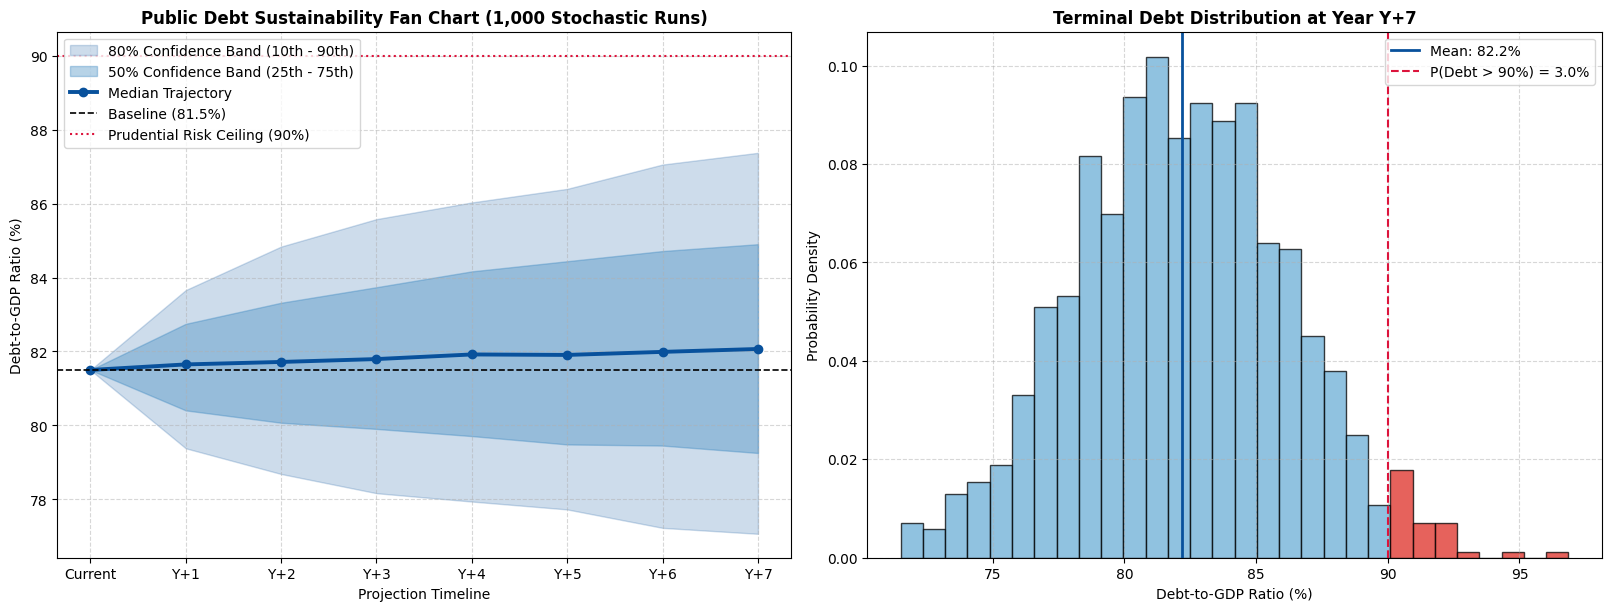

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Macroeconomic Fan Chart (IMF Style) ---
x_axis = np.arange(len(timeline))

# Shaded Percentile Confidence Bands
ax1.fill_between(
    x_axis,
    p10,
    p90,
    color="#08519c",
    alpha=0.20,
    label="80% Confidence Band (10th - 90th)",
)
ax1.fill_between(
    x_axis,
    p25,
    p75,
    color="#3182bd",
    alpha=0.35,
    label="50% Confidence Band (25th - 75th)",
)

# Plot Baseline & Median Path
ax1.plot(
    x_axis,
    p50,
    color="#08519c",
    linewidth=2.8,
    marker="o",
    label="Median Trajectory",
)
ax1.axhline(
    INITIAL_DEBT_RATIO,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Baseline ({INITIAL_DEBT_RATIO}%)",
)
ax1.axhline(
    90.0,
    color="crimson",
    linestyle=":",
    linewidth=1.5,
    label="Prudential Risk Ceiling (90%)",
)

ax1.set_title(
    "Public Debt Sustainability Fan Chart (1,000 Stochastic Runs)",
    fontsize=12,
    weight="bold",
)
ax1.set_xlabel("Projection Timeline")
ax1.set_ylabel("Debt-to-GDP Ratio (%)")
ax1.set_xticks(x_axis)
ax1.set_xticklabels(timeline)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# --- Chart 2: Terminal Debt Probability Distribution (Y+7) ---
n, bins, patches = ax2.hist(
    terminal_debt,
    bins=30,
    density=True,
    color="#6baed6",
    edgecolor="black",
    alpha=0.75,
)

# Highlight high-risk region (>90%)
for bin_left, patch in zip(bins[:-1], patches):
    if bin_left >= 90.0:
        patch.set_facecolor("#de2d26")

ax2.axvline(
    terminal_debt.mean(),
    color="#08519c",
    linewidth=2,
    label=f"Mean: {terminal_debt.mean():.1f}%",
)
ax2.axvline(
    90.0,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"P(Debt > 90%) = {prob_debt_exceeds_90:.1f}%",
)

ax2.set_title(
    f"Terminal Debt Distribution at Year Y+{YEARS}", fontsize=12, weight="bold"
)
ax2.set_xlabel("Debt-to-GDP Ratio (%)")
ax2.set_ylabel("Probability Density")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

plt.show()